In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, IntegerType, StructType, StructField, FloatType 
import numpy as np
import pandas as pd # Still needed for feature importance plotting

# ML specific imports
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import Imputer, StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

In [2]:
try:
    from xgboost.spark import SparkXGBClassifier as XgboostClassifier # Use alias for consistency
    print("Using xgboost.spark.SparkXGBClassifier")
except ImportError:
    print("Error: xgboost.spark not found or xgboost library not installed.")
    print("Please install xgboost: pip install xgboost")
    XgboostClassifier = None # Placeholder if import fails

import warnings
warnings.filterwarnings('ignore')

# Import for plotting (requires collecting data to driver)
import matplotlib.pyplot as plt
import sys
import os 

Using xgboost.spark.SparkXGBClassifier


In [3]:
spark = (
    SparkSession.builder
    .appName("Assignment--ML-LogisticRegression")
    .config("spark.driver.memory", "8g")
    .getOrCreate()
)

In [4]:
spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")
spark.conf.set("spark.sql.execution.arrow.maxRecordsPerBatch", "100000")

In [5]:
temp_df = spark.read.csv('./HC_application_train.csv', header=True, inferSchema=True)
print("Inferred Schema:")
temp_df.printSchema()

Inferred Schema:
root
 |-- SK_ID_CURR: integer (nullable = true)
 |-- TARGET: integer (nullable = true)
 |-- NAME_CONTRACT_TYPE: string (nullable = true)
 |-- CODE_GENDER: string (nullable = true)
 |-- FLAG_OWN_CAR: string (nullable = true)
 |-- FLAG_OWN_REALTY: string (nullable = true)
 |-- CNT_CHILDREN: integer (nullable = true)
 |-- AMT_INCOME_TOTAL: double (nullable = true)
 |-- AMT_CREDIT: double (nullable = true)
 |-- AMT_ANNUITY: double (nullable = true)
 |-- AMT_GOODS_PRICE: double (nullable = true)
 |-- NAME_TYPE_SUITE: string (nullable = true)
 |-- NAME_INCOME_TYPE: string (nullable = true)
 |-- NAME_EDUCATION_TYPE: string (nullable = true)
 |-- NAME_FAMILY_STATUS: string (nullable = true)
 |-- NAME_HOUSING_TYPE: string (nullable = true)
 |-- REGION_POPULATION_RELATIVE: double (nullable = true)
 |-- DAYS_BIRTH: integer (nullable = true)
 |-- DAYS_EMPLOYED: integer (nullable = true)
 |-- DAYS_REGISTRATION: double (nullable = true)
 |-- DAYS_ID_PUBLISH: integer (nullable = true

In [6]:
column_names = temp_df.columns

In [7]:
categorical_flags_cols = {
    "NAME_CONTRACT_TYPE", "CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY",
    "FLAG_MOBIL", "FLAG_EMP_PHONE", "FLAG_WORK_PHONE", "FLAG_CONT_MOBILE",
    "FLAG_PHONE", "FLAG_EMAIL", "REGION_RATING_CLIENT", "REGION_RATING_CLIENT_W_CITY",
    "REG_REGION_NOT_LIVE_REGION", "REG_REGION_NOT_WORK_REGION", "LIVE_REGION_NOT_WORK_REGION",
    "REG_CITY_NOT_LIVE_CITY", "REG_CITY_NOT_WORK_CITY", "LIVE_CITY_NOT_WORK_CITY",
    # Add ALL credit status/type/currency columns if they are categorical/flags
    "CREDIT_ACTIVE_Active", "CREDIT_ACTIVE_Bad debt", "CREDIT_ACTIVE_Closed", "CREDIT_ACTIVE_Sold",
    "CREDIT_CURRENCY_currency 1", "CREDIT_CURRENCY_currency 2", "CREDIT_CURRENCY_currency 3", "CREDIT_CURRENCY_currency 4",
    "CREDIT_TYPE_Another type of loan", "CREDIT_TYPE_Car loan", "CREDIT_TYPE_Cash loan (non-earmarked)",
    "CREDIT_TYPE_Consumer credit", "CREDIT_TYPE_Credit card", "CREDIT_TYPE_Interbank credit",
    "CREDIT_TYPE_Loan for business development", "CREDIT_TYPE_Loan for purchase of shares (margin lending)",
    "CREDIT_TYPE_Loan for the purchase of equipment", "CREDIT_TYPE_Loan for working capital replenishment",
    "CREDIT_TYPE_Microloan", "CREDIT_TYPE_Mobile operator loan", "CREDIT_TYPE_Mortgage",
    "CREDIT_TYPE_Real estate loan", "CREDIT_TYPE_Unknown type of loan",
    "NAME_CONTRACT_STATUS_Approved", "NAME_CONTRACT_STATUS_Canceled", "NAME_CONTRACT_STATUS_Completed",
    "NAME_CONTRACT_STATUS_Demand", "NAME_CONTRACT_STATUS_Refused", "NAME_CONTRACT_STATUS_Sent proposal",
    "NAME_CONTRACT_STATUS_Signed",
    # *** ADD THE PROBLEMATIC COLUMNS AND SIMILAR ONES HERE ***
     "NAME_TYPE_SUITE", "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE",
     "OCCUPATION_TYPE", "WEEKDAY_APPR_PROCESS_START", "ORGANIZATION_TYPE", "FONDKAPREMONT_MODE",
     "HOUSETYPE_MODE", "WALLSMATERIAL_MODE", "EMERGENCYSTATE_MODE"
}
id_target_cols = {"SK_ID_CURR", "TARGET"}

print("Defining schema...")
schema_fields = []
for col in column_names:
    if col in id_target_cols:
        field_type = IntegerType()
    elif col in categorical_flags_cols:
        # If these columns contain actual strings in the CSV, use StringType()
        # If they are guaranteed to be integers (like 0/1 flags or codes), IntegerType() is okay
        # Let's assume they might be strings or numerically coded categories, keep Integer for now
        # BUT crucially, we won't impute them with median/mean later.
        field_type = IntegerType()
        print(f"  Column '{col}' defined as CATEGORICAL/FLAG (IntegerType)")
    else:
        # Assume remaining are numeric (Double/Float)
        field_type = DoubleType() # Or FloatType()
        print(f"  Column '{col}' defined as NUMERIC (DoubleType)")
    schema_fields.append(StructField(col, field_type, True))

schema = StructType(schema_fields)
schema["TARGET"].dataType = IntegerType()
print("Schema defined.")

Defining schema...
  Column 'NAME_CONTRACT_TYPE' defined as CATEGORICAL/FLAG (IntegerType)
  Column 'CODE_GENDER' defined as CATEGORICAL/FLAG (IntegerType)
  Column 'FLAG_OWN_CAR' defined as CATEGORICAL/FLAG (IntegerType)
  Column 'FLAG_OWN_REALTY' defined as CATEGORICAL/FLAG (IntegerType)
  Column 'CNT_CHILDREN' defined as NUMERIC (DoubleType)
  Column 'AMT_INCOME_TOTAL' defined as NUMERIC (DoubleType)
  Column 'AMT_CREDIT' defined as NUMERIC (DoubleType)
  Column 'AMT_ANNUITY' defined as NUMERIC (DoubleType)
  Column 'AMT_GOODS_PRICE' defined as NUMERIC (DoubleType)
  Column 'NAME_TYPE_SUITE' defined as CATEGORICAL/FLAG (IntegerType)
  Column 'NAME_INCOME_TYPE' defined as CATEGORICAL/FLAG (IntegerType)
  Column 'NAME_EDUCATION_TYPE' defined as CATEGORICAL/FLAG (IntegerType)
  Column 'NAME_FAMILY_STATUS' defined as CATEGORICAL/FLAG (IntegerType)
  Column 'NAME_HOUSING_TYPE' defined as CATEGORICAL/FLAG (IntegerType)
  Column 'REGION_POPULATION_RELATIVE' defined as NUMERIC (DoubleType)


In [8]:
# Load data using Spark
df = spark.read.csv('./HC_application_train.csv', header=True, schema=schema, nanValue='NA', nullValue=None)

In [9]:
# --- Basic Data Exploration ---
print("DataFrame Schema:")
df.printSchema()
print("\nSample Data:")
df.show(5, truncate=False) # Show more content if needed
print(f"\nTotal rows before deduplication: {df.count()}")
initial_count = df.count()
df = df.dropDuplicates() # Remove duplicates
duplicates_count = initial_count - df.count()
print(f"Number of duplicate rows removed: {duplicates_count}")
print(f"Total rows after deduplication: {df.count()}")

DataFrame Schema:
root
 |-- SK_ID_CURR: integer (nullable = true)
 |-- TARGET: integer (nullable = true)
 |-- NAME_CONTRACT_TYPE: integer (nullable = true)
 |-- CODE_GENDER: integer (nullable = true)
 |-- FLAG_OWN_CAR: integer (nullable = true)
 |-- FLAG_OWN_REALTY: integer (nullable = true)
 |-- CNT_CHILDREN: double (nullable = true)
 |-- AMT_INCOME_TOTAL: double (nullable = true)
 |-- AMT_CREDIT: double (nullable = true)
 |-- AMT_ANNUITY: double (nullable = true)
 |-- AMT_GOODS_PRICE: double (nullable = true)
 |-- NAME_TYPE_SUITE: integer (nullable = true)
 |-- NAME_INCOME_TYPE: integer (nullable = true)
 |-- NAME_EDUCATION_TYPE: integer (nullable = true)
 |-- NAME_FAMILY_STATUS: integer (nullable = true)
 |-- NAME_HOUSING_TYPE: integer (nullable = true)
 |-- REGION_POPULATION_RELATIVE: double (nullable = true)
 |-- DAYS_BIRTH: double (nullable = true)
 |-- DAYS_EMPLOYED: double (nullable = true)
 |-- DAYS_REGISTRATION: double (nullable = true)
 |-- DAYS_ID_PUBLISH: double (nullable 

In [10]:
# --- Feature Preparation ---
all_feature_cols = [col for col in df.columns if col not in ['SK_ID_CURR', 'TARGET']]

# Identify TRUE numeric columns (exclude categorical/flags)
true_numeric_cols = [
    f.name for f in df.schema.fields
    if isinstance(f.dataType, (DoubleType, IntegerType, FloatType)) # Check type from schema
    and f.name in all_feature_cols
    and f.name not in categorical_flags_cols # *** Ensure exclusion ***
]

# Identify categorical/flag columns that are features
categorical_feature_cols = [col for col in all_feature_cols if col in categorical_flags_cols]

print(f"\nIdentified {len(true_numeric_cols)} true numeric columns for imputation.")
print(f"Identified {len(categorical_feature_cols)} categorical/flag feature columns.")

# --- Check and Impute TRUE Numeric Columns ---
print("\nChecking for null/NaN values in TRUE numeric feature columns:")
# It's more efficient to calculate counts only for columns that might be imputed
df.select(true_numeric_cols).summary("count").show() # Shows non-null counts

# Select columns that actually have nulls to impute
numeric_cols_to_impute = []
df_count = df.count()
null_check_exprs = [F.sum(F.when(F.col(c).isNull() | F.isnan(c), 1).otherwise(0)).alias(c) for c in true_numeric_cols]
null_counts_result = df.select(null_check_exprs).first().asDict()

for col in true_numeric_cols:
    if null_counts_result[col] > 0:
        numeric_cols_to_impute.append(col)

imputed_numeric_output_cols = []
if numeric_cols_to_impute:
    print(f"Numeric columns with null/NaN values needing imputation: {len(numeric_cols_to_impute)}")
    # Print top N columns with most nulls if desired
    # null_counts_filtered = {k:v for k,v in null_counts_result.items() if k in numeric_cols_to_impute and v > 0}
    # sorted_nulls_numeric = sorted(null_counts_filtered.items(), key=lambda item: item[1], reverse=True)
    # for col, count in sorted_nulls_numeric[:20]: print(f"  - {col}: {count}")

    print("\nSetting up Imputer for numeric columns...")
    imputed_numeric_output_cols = [f"{c}_imputed" for c in numeric_cols_to_impute]
    imputer = Imputer(
        inputCols=numeric_cols_to_impute,
        outputCols=imputed_numeric_output_cols,
        strategy="median"
    )
    print("Fitting Imputer...")
    imputer_model = imputer.fit(df)
    print("Transforming data with Imputer...")
    df_processed = imputer_model.transform(df)
    # Keep original numeric cols that didn't need imputation
    numeric_cols_no_impute = [c for c in true_numeric_cols if c not in numeric_cols_to_impute]
    final_numeric_cols = numeric_cols_no_impute + imputed_numeric_output_cols

else:
    print("No null/NaN values found in TRUE numeric feature columns. Skipping Imputation step for them.")
    df_processed = df # Use the original df
    final_numeric_cols = true_numeric_cols # Use original names

# --- Handle Nulls in CATEGORICAL/FLAG Columns ---
# Check for nulls in categorical columns again on df_processed
print("\nChecking for null/NaN values in CATEGORICAL/FLAG feature columns:")
df_processed.select(categorical_feature_cols).summary("count").show()

cat_null_check_exprs = [F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c) for c in categorical_feature_cols]
cat_null_counts_result = df_processed.select(cat_null_check_exprs).first().asDict()
categorical_cols_to_fill = [col for col, count in cat_null_counts_result.items() if count > 0]

if categorical_cols_to_fill:
    print(f"Categorical/Flag columns with nulls needing filling: {len(categorical_cols_to_fill)}")
    # Option: Fill with a constant (e.g., -1 if it's not a valid category, or 0 for flags)
    print("Filling nulls in categorical/flag columns with -1 (adjust if needed)")
    # Ensure fillna only targets the columns that actually had nulls identified
    df_processed = df_processed.fillna(-1, subset=categorical_cols_to_fill)
else:
    print("No null values found in categorical/flag feature columns.")


Identified 90 true numeric columns for imputation.
Identified 30 categorical/flag feature columns.

Checking for null/NaN values in TRUE numeric feature columns:
+-------+------------+----------------+----------+-----------+---------------+--------------------------+----------+-------------+-----------------+---------------+-----------+---------------+-----------------------+------------+------------+------------+--------------+----------------+---------------------------+---------------+--------------+-------------+-------------+-------------+-------------+------------+--------------------+--------------+-----------------------+-----------------+---------------+-----------------+----------------------------+----------------+---------------+--------------+--------------+--------------+--------------+-------------+---------------------+---------------+------------------------+------------------+---------------+-----------------+----------------------------+----------------+------------

In [11]:
# --- Assembler ---
# Combine imputed/original numeric columns and original/filled categorical columns
final_feature_cols_for_assembler = final_numeric_cols + categorical_feature_cols
print(f"\nAssembling {len(final_feature_cols_for_assembler)} features...")

assembler = VectorAssembler(
    inputCols=final_feature_cols_for_assembler,
    outputCol="features",
    handleInvalid="error" # Be strict now
)

print("Assembling features...")
try:
    df_assembled = assembler.transform(df_processed).select("SK_ID_CURR", "features", "TARGET")
    df_assembled.cache()
    assembled_count = df_assembled.count()
    print(f"Feature assembly successful. Rows after assembly: {assembled_count}")
    if assembled_count == 0:
        print("WARNING: DataFrame became empty after assembly, likely due to handleInvalid='error' and remaining nulls.")
        spark.stop(); sys.exit(1)
except Exception as e:
    print(f"Error during final feature assembly: {e}")
    spark.stop(); sys.exit(1)


Assembling 120 features...
Assembling features...
Feature assembly successful. Rows after assembly: 307511


In [12]:
def evaluate_spark_model(model, predictions_train, predictions_test, label_col="TARGET", pred_col = "prediction"):
    """Evaluates a PySpark binary classification model."""
    print("\n--- Model Evaluation ---")
    evaluator_roc = BinaryClassificationEvaluator(labelCol=label_col, rawPredictionCol="rawPrediction", metricName="areaUnderROC")
    evaluator_multi = MulticlassClassificationEvaluator(labelCol=label_col, predictionCol=pred_col)
    def get_recall_label_1(predictions):
        try: return evaluator_multi.evaluate(predictions, {evaluator_multi.metricName: "recallByLabel", evaluator_multi.metricLabel: 1.0})
        except Exception: actual_1_count = predictions.filter(F.col(label_col) == 1).count(); return float('nan') if actual_1_count == 0 else 0.0
    auc_train = evaluator_roc.evaluate(predictions_train); accuracy_train = evaluator_multi.evaluate(predictions_train, {evaluator_multi.metricName: "accuracy"}); f1_train = evaluator_multi.evaluate(predictions_train, {evaluator_multi.metricName: "f1"})
    print(f"Accuracy (Train Set)    : {accuracy_train:.2f}"); print(f"F1-Score (Train Set)    : {f1_train:.2f}"); print(f"ROC-AUC (Train Set)     : {auc_train:.2f}")
    auc_test = evaluator_roc.evaluate(predictions_test); accuracy_test = evaluator_multi.evaluate(predictions_test, {evaluator_multi.metricName: "accuracy"}); precision_test = evaluator_multi.evaluate(predictions_test, {evaluator_multi.metricName: "precisionByLabel", evaluator_multi.metricLabel: 1.0}); recall_test = get_recall_label_1(predictions_test); f1_test = evaluator_multi.evaluate(predictions_test, {evaluator_multi.metricName: "f1"})
    print(f"\nAccuracy (Test Set)     : {accuracy_test:.2f}"); print(f"Precision (Test Set)    : {precision_test:.2f}"); print(f"Recall (Test Set)       : {recall_test:.2f}"); print(f"F1-Score (Test Set)     : {f1_test:.2f}"); print(f"ROC-AUC (Test Set)      : {auc_test:.2f}")
    print("\nConfusion Matrix (Test Set):"); predictions_test.select(label_col, pred_col).crosstab(label_col, pred_col).orderBy(F.col(f"{label_col}_{pred_col}").asc()).show()

In [13]:
def show_spark_feature_importance(model, features_list):
    print("\n--- Feature Importance ---")
    try:
        if hasattr(model, '_xgb_sklearn_model'): importances = model._xgb_sklearn_model.get_booster().get_score(importance_type='weight')
        elif hasattr(model, 'get_booster'): importances = model.get_booster().get_score(importance_type='weight')
        else:
            if hasattr(model, 'featureImportances'): imp_vector = model.featureImportances; importances = {f'f{i}': imp_vector[i] for i in range(len(features_list)) if imp_vector[i] > 0}
            else: print("Could not retrieve feature importances."); return
        if not importances: print("Could not retrieve feature importances (empty score dictionary or zero vector)."); return
        # Map feature indices (f0, f1, ...) back to original feature names
        feat_imp_dict = {}
        for i, feat_name in enumerate(final_feature_cols_for_assembler): # Use the list fed to assembler
            feat_key = f'f{i}';
            if feat_key in importances: feat_imp_dict[feat_name] = importances[feat_key]
        if not feat_imp_dict:
             if all(feat in final_feature_cols_for_assembler for feat in importances.keys()): feat_imp_dict = importances
             else: print("Could not map feature indices to names or names not directly available."); return
        feat_importances_pd = pd.Series(feat_imp_dict).sort_values(ascending=False)
        plt.figure(figsize=(10, 8)); ax = feat_importances_pd.nlargest(25).plot(kind='barh'); ax.invert_yaxis()
        plt.xlabel('Importance Score (Weight)'); plt.ylabel('Feature'); plt.title('Feature Importance'); plt.tight_layout(); plt.show()
    except Exception as e: print(f"Error retrieving/plotting feature importances: {e}")

In [14]:
# def calculate_spark_default_rate_simplified(predictions, dataset_name="dataset", label_col="TARGET", prob_col="probability", threshold=0.5):
#     print(f"\n--- Simplified Default Rate Calculation ({dataset_name}) ---")
#     if prob_col not in predictions.columns: print(f"Error: Probability column '{prob_col}' not found."); return 0.0
#     try: pred_df = predictions.withColumn("prob_1", F.element_at(F.col(prob_col), 2))
#     except: from pyspark.ml.functions import vector_to_array; pred_df = predictions.withColumn("prob_array", vector_to_array(F.col(prob_col))).withColumn("prob_1", F.col("prob_array")[1])
#     pred_df = pred_df.withColumn("predicted_default", F.when(F.col("prob_1") > threshold, 1).otherwise(0))

#     # Try just counting the defaults
#     try:
#         pred_default_count = pred_df.filter(F.col("predicted_default") == 1).count()
#         total_count = pred_df.count() # Get total count separately
#         print(f"Simplified - Predicted Default Count: {pred_default_count}")
#         print(f"Simplified - Total Count: {total_count}")
#         if total_count > 0:
#              default_rate = pred_default_count / total_count
#              print(f"Tingkat default prediksi: {default_rate:.2%}")
#              return default_rate
#         else:
#              return 0.0
#     except Exception as e:
#          print(f"Error during simplified count: {e}")
#          return 0.0

In [15]:
def handle_outliers_iqr(data, columns):
    print("Applying IQR capping to training data...")
    df_out = data; stats = data.select([F.expr(f"percentile_approx(`{col}`, 0.25)").alias(f"{col}_q1") for col in columns] + [F.expr(f"percentile_approx(`{col}`, 0.75)").alias(f"{col}_q3") for col in columns]).first().asDict()
    for col in columns:
        q1 = stats.get(f"{col}_q1"); q3 = stats.get(f"{col}_q3")
        if q1 is not None and q3 is not None: iqr = q3 - q1; lower_bound = q1 - 1.5 * iqr; upper_bound = q3 + 1.5 * iqr; print(f" Capping {col}: Lower={lower_bound:.2f}, Upper={upper_bound:.2f}"); df_out = df_out.withColumn(col, F.when(F.col(col) < lower_bound, F.lit(lower_bound)).when(F.col(col) > upper_bound, F.lit(upper_bound)).otherwise(F.col(col)))
        else: print(f" Skipping {col}: Could not calculate quantiles (likely nulls or constant value)")
    return df_out

In [16]:
def apply_train_iqr_bounds(data, train_stats, columns):
    print("Applying IQR capping to test data using train bounds...")
    df_out = data
    for col in columns:
        q1 = train_stats.get(f"{col}_q1"); q3 = train_stats.get(f"{col}_q3")
        if q1 is not None and q3 is not None: iqr = q3 - q1; lower_bound = q1 - 1.5 * iqr; upper_bound = q3 + 1.5 * iqr; df_out = df_out.withColumn(col, F.when(F.col(col) < lower_bound, F.lit(lower_bound)).when(F.col(col) > upper_bound, F.lit(upper_bound)).otherwise(F.col(col)))
        else: print(f" Skipping {col} for test capping: bounds not available from train data.")
    return df_out

In [17]:
# --- Data without Preprocessing (Baseline Setup) ---
print("\n--- Baseline Model (No Undersampling/Weighting/IQR) ---")
train_df_baseline, test_df_baseline = df_assembled.drop("SK_ID_CURR").randomSplit([0.8, 0.2], seed=42)
train_df_baseline.cache()
test_df_baseline.cache()


--- Baseline Model (No Undersampling/Weighting/IQR) ---


DataFrame[features: vector, TARGET: int]

Number of rows in train_df_baseline BEFORE fitting: 246396

Training Baseline XGBoost model...


2025-04-21 09:22:40,947 INFO XGBoost-PySpark: _fit Running xgboost-3.0.0 on 1 workers with
	booster params: {'objective': 'binary:logistic', 'device': 'cpu', 'random_state': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 100}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2025-04-21 09:23:19,156 INFO XGBoost-PySpark: _fit Finished xgboost training!



Evaluating Baseline Model...

--- Model Evaluation ---
Accuracy (Train Set)    : 0.92
F1-Score (Train Set)    : 0.89
ROC-AUC (Train Set)     : 0.85

Accuracy (Test Set)     : 0.92
Precision (Test Set)    : 0.44
Recall (Test Set)       : 0.03
F1-Score (Test Set)     : 0.89
ROC-AUC (Test Set)      : 0.74

Confusion Matrix (Test Set):
+-----------------+-----+---+
|TARGET_prediction|  0.0|1.0|
+-----------------+-----+---+
|                0|56013|194|
|                1| 4758|150|
+-----------------+-----+---+


--- Feature Importance ---


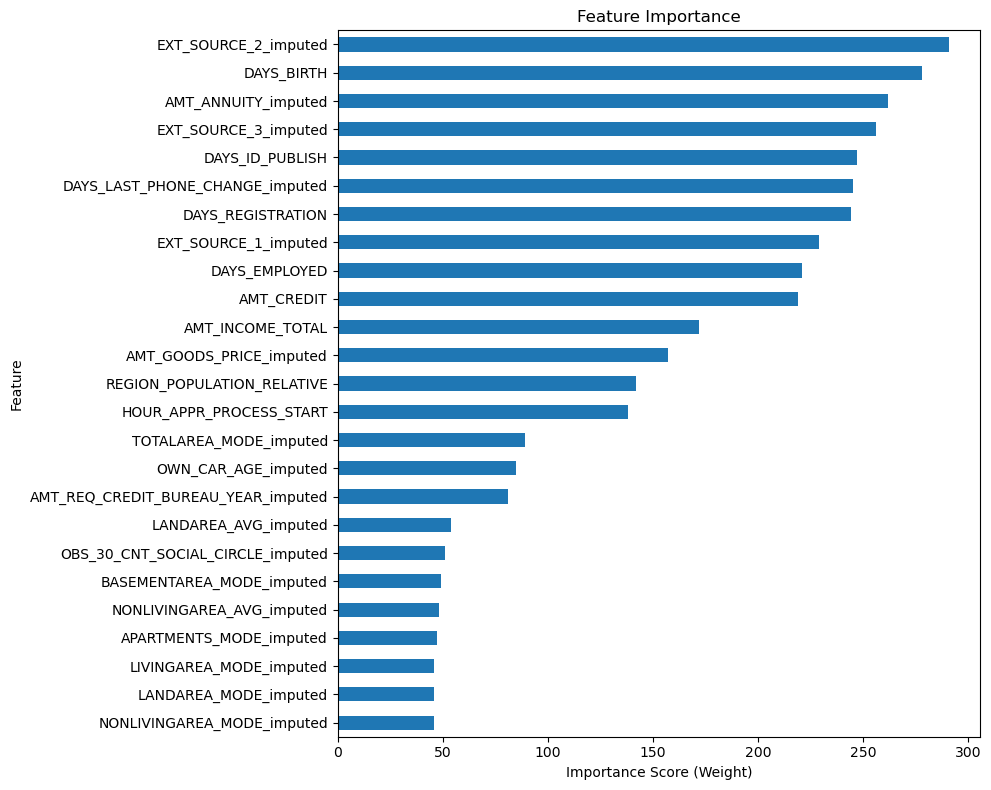

In [18]:
# --- Train and Evaluate Baseline XGBoost Model ---
train_baseline_count = train_df_baseline.count()
print(f"Number of rows in train_df_baseline BEFORE fitting: {train_baseline_count}")
if XgboostClassifier and train_baseline_count > 0:
    print("\nTraining Baseline XGBoost model...")
    xgb_baseline = XgboostClassifier(features_col="features", label_col="TARGET", random_state=42, use_gpu=False)
    try:
        xgb_model_baseline = xgb_baseline.fit(train_df_baseline)
        print("\nEvaluating Baseline Model...")
        predictions_train_baseline = xgb_model_baseline.transform(train_df_baseline)
        predictions_test_baseline = xgb_model_baseline.transform(test_df_baseline)
        evaluate_spark_model(xgb_model_baseline, predictions_train_baseline, predictions_test_baseline)
        # Use the final assembled list for mapping importance
        show_spark_feature_importance(xgb_model_baseline, final_feature_cols_for_assembler)
        # calculate_spark_default_rate_simplified(predictions_train_baseline, dataset_name="Train (Baseline)")
        # calculate_spark_default_rate_simplified(predictions_test_baseline, dataset_name="Test (Baseline)")
    except IndexError as ie: print(f"IndexError during baseline fit: {ie}. RDD likely empty.")
    except Exception as e: print(f"An unexpected error occurred during baseline fit: {e}")
elif not XgboostClassifier: print("\nXGBoostClassifier not available. Skipping baseline model training.")
else: print("\nSkipping baseline model training because train_df_baseline is empty.")


--- Model with Class Weighting ---
Calculated scale_pos_weight: 11.371140231962645

Training XGBoost model with class weights...


2025-04-21 09:24:47,559 INFO XGBoost-PySpark: _fit Running xgboost-3.0.0 on 1 workers with
	booster params: {'objective': 'binary:logistic', 'device': 'cpu', 'random_state': 42, 'scale_pos_weight': 11.371140231962645, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 100}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2025-04-21 09:25:22,704 INFO XGBoost-PySpark: _fit Finished xgboost training!



Evaluating Weighted Model...

--- Model Evaluation ---
Accuracy (Train Set)    : 0.76
F1-Score (Train Set)    : 0.81
ROC-AUC (Train Set)     : 0.86

Accuracy (Test Set)     : 0.73
Precision (Test Set)    : 0.17
Recall (Test Set)       : 0.60
F1-Score (Test Set)     : 0.79
ROC-AUC (Test Set)      : 0.73

Confusion Matrix (Test Set):
+-----------------+-----+-----+
|TARGET_prediction|  0.0|  1.0|
+-----------------+-----+-----+
|                0|41405|14802|
|                1| 1960| 2948|
+-----------------+-----+-----+


--- Feature Importance ---


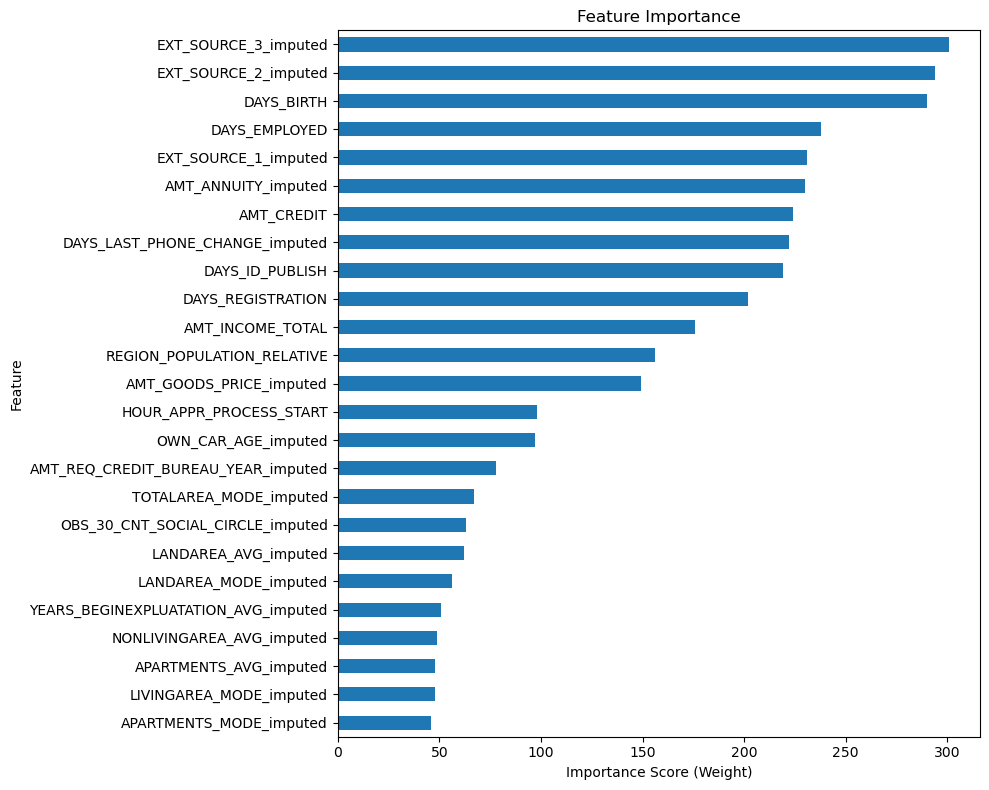

In [19]:
# --- Class Weighting ---
# ... (Keep the Class Weighting code block, using train_df_baseline) ...
print("\n--- Model with Class Weighting ---")
# Use the baseline train/test splits which come from the assembled+imputed data
if train_df_baseline.is_cached and test_df_baseline.is_cached:
    count0 = train_df_baseline.filter(F.col("TARGET") == 0).count()
    count1 = train_df_baseline.filter(F.col("TARGET") == 1).count()
    if count1 > 0:
        scale_pos_weight_val = count0 / count1
        print(f"Calculated scale_pos_weight: {scale_pos_weight_val}")
        if XgboostClassifier and train_df_baseline.count() > 0:
            print("\nTraining XGBoost model with class weights...")
            xgb_weighted = XgboostClassifier(features_col="features", label_col="TARGET", scale_pos_weight=scale_pos_weight_val, random_state=42, use_gpu=False)
            try:
                xgb_model_weighted = xgb_weighted.fit(train_df_baseline)
                print("\nEvaluating Weighted Model...")
                predictions_train_weighted_eval = xgb_model_weighted.transform(train_df_baseline)
                predictions_test_weighted_eval = xgb_model_weighted.transform(test_df_baseline)
                evaluate_spark_model(xgb_model_weighted, predictions_train_weighted_eval, predictions_test_weighted_eval)
                show_spark_feature_importance(xgb_model_weighted, final_feature_cols_for_assembler)
                # calculate_spark_default_rate(predictions_train_weighted_eval, dataset_name="Train (Weighted)")
                # calculate_spark_default_rate(predictions_test_weighted_eval, dataset_name="Test (Weighted)")
            except IndexError as ie: print(f"IndexError during weighted fit: {ie}. RDD likely empty.")
            except Exception as e: print(f"An unexpected error occurred during weighted fit: {e}")
        elif not XgboostClassifier: print("\nXGBoostClassifier not available. Skipping weighted model training.")
        else: print("\nSkipping weighted model training because train_df_baseline is empty.")
    else: print("\nCannot calculate scale_pos_weight, skipping weighted model training (count of class 1 is zero).")
else:
    print("\nSkipping Class Weighting step because baseline dataframes are not available/cached.")

In [20]:
# --- Clean up ---
print("\nCleaning up cached DataFrames...")
if 'df_assembled' in locals() and df_assembled.is_cached: df_assembled.unpersist()
if 'train_df_split' in locals() and train_df_split.is_cached: train_df_split.unpersist()
if 'test_df_split' in locals() and test_df_split.is_cached: test_df_split.unpersist()
# Clear all cache as a final step if desired
spark.catalog.clearCache()

# Stop Spark Session
spark.stop()
print("\nSpark session stopped.")


Cleaning up cached DataFrames...

Spark session stopped.
